In [18]:
import polars as pl
from collections import Counter
import matplotlib.pyplot as plt
import json

/tmp/ipykernel_923241/1745985214.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


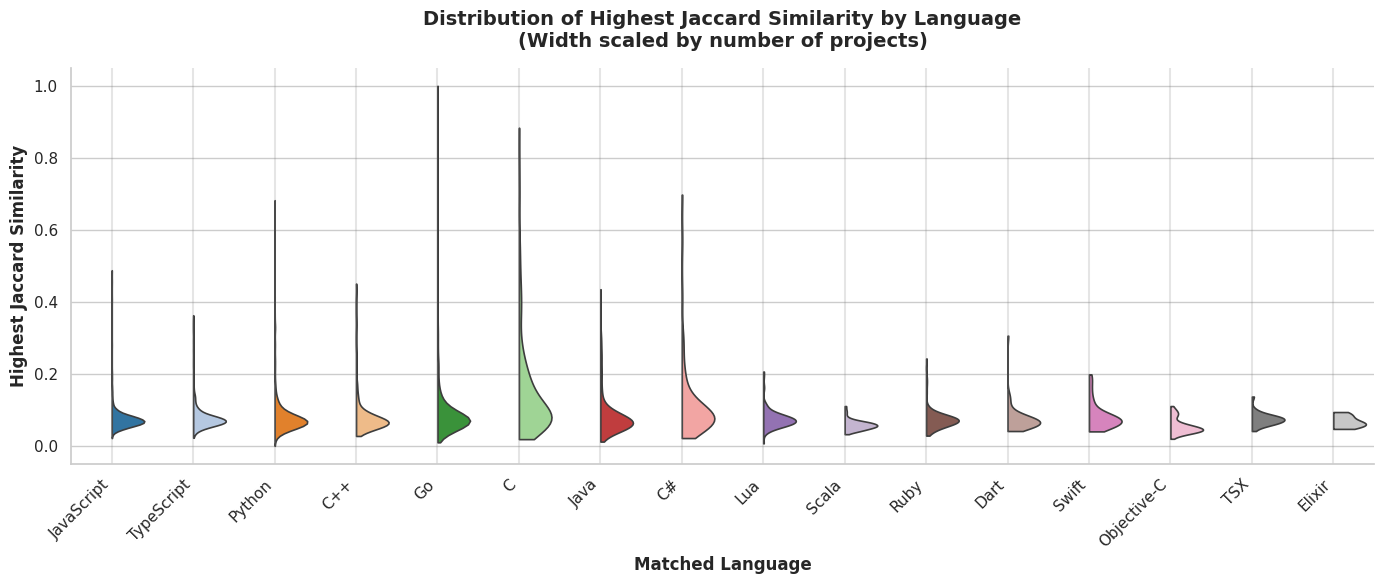

In [ ]:
df = pl.read_csv("../../migration-status/results/final_symbols_compare_2.csv", has_header=False, new_columns=["from", "index", "to", "language", "jaccard"])
df_rust = pl.read_csv("../../migration-status/results/repositories_with_rust_over_250_stars.csv", has_header=False, new_columns=["language", "name", "stars", "percentage", "languages"])

results = []

for project in df["from"].unique():
    rust_item = df_rust.filter(pl.col("name") == project)
    if rust_item.height == 0 or rust_item.select("stars").row(0)[0] < 300:
        continue
    languages = json.loads(rust_item.select("languages").row(0)[0])
    rust_size = languages.get("Rust", 0)

    item = df.filter((pl.col("from") == project) & (pl.col("index") == 0)).select(["language", "jaccard", "to"])
    if item.height == 0:
        continue
    item = item.row(0)

    if rust_size < 10000:
        continue
    if item[1] > 0.5:
        print(f"Project: {project}, Language: {item[0]}, To: {item[2]}, Jaccard: {item[1]:.2f}, Rust Size: {rust_size}")
    results.append((item[0], item[1]))

lang_counts = Counter([x[0] for x in results])
sorted_langs = [lang for lang, _ in lang_counts.most_common()]

stacked_values = []
for lang in sorted_langs:
    values = [x[1] for x in results if x[0] == lang]
    stacked_values.append(values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
colors = plt.cm.tab20.colors[:len(sorted_langs)]

ax1.hist(stacked_values, bins=20, range=(0, 0.15), stacked=True, label=sorted_langs, edgecolor='black', color=colors)
ax1.set_xlabel("Highest jaccard similarity")
ax1.set_ylabel("Number of projects")
ax1.grid(True, which='both', ls='--', alpha=0.4)

ax2.hist(stacked_values, bins=20, range=(0.15, 1.0), stacked=True, label=sorted_langs, edgecolor='black', color=colors)
ax2.set_xlabel("Highest jaccard similarity")
ax2.grid(True, which='both', ls='--', alpha=0.4)

ax2.legend(title="Matched Language", bbox_to_anchor=(1.05, 1), loc='upper left')

fig.suptitle("Distribution of highest jaccard similarity of matches by language", fontsize=14)

plt.tight_layout()
plt.show()

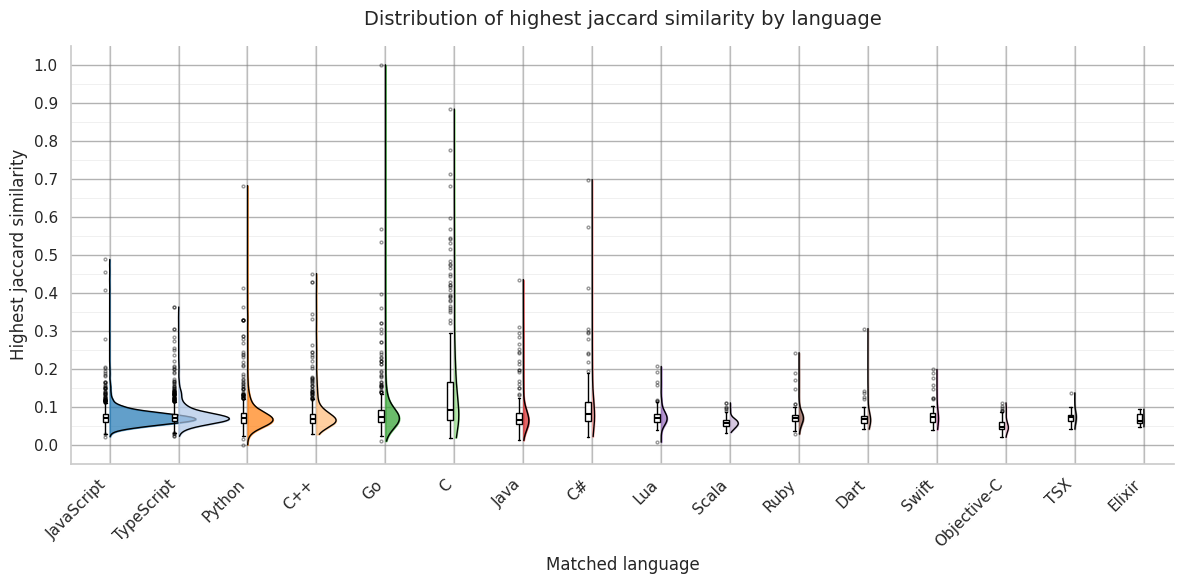

In [ ]:
import polars as pl
import json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
from scipy.stats import gaussian_kde

# --- 1. Data Processing ---
df = pl.read_csv("../../migration-status/results/final_symbols_compare_2.csv", has_header=False, new_columns=["from", "index", "to", "language", "jaccard"])
df_rust = pl.read_csv("../../migration-status/results/repositories_with_rust_over_250_stars.csv", has_header=False, new_columns=["language", "name", "stars", "percentage", "languages"])

results = []

for project in df["from"].unique():
    rust_item = df_rust.filter(pl.col("name") == project)
    if rust_item.height == 0 or rust_item.select("stars").row(0)[0] < 300:
        continue
    languages = json.loads(rust_item.select("languages").row(0)[0])
    rust_size = languages.get("Rust", 0)

    item = df.filter((pl.col("from") == project) & (pl.col("index") == 0)).select(["language", "jaccard", "to"])
    if item.height == 0:
        continue
    item = item.row(0)

    if rust_size < 10000:
        continue
    if item[1] > 0.5:
        pass 
    results.append((item[0], item[1]))

df_plot = pd.DataFrame(results, columns=["language", "jaccard"])
lang_counts = Counter(df_plot["language"])
sorted_langs = [lang for lang, _ in lang_counts.most_common()]

# --- 2. Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))
x_positions = np.arange(len(sorted_langs))
colors = plt.cm.tab20.colors

# Calculate exact absolute densities
kdes = {}
y_grids = {}
max_density_global = 0

for lang in sorted_langs:
    data = df_plot[df_plot["language"] == lang]["jaccard"].values
    if len(data) > 1:
        kde = gaussian_kde(data)
        y_grid = np.linspace(min(data), max(data), 200)
        absolute_density = kde.evaluate(y_grid) * len(data) 
        
        kdes[lang] = absolute_density
        y_grids[lang] = y_grid
        
        if max(absolute_density) > max_density_global:
            max_density_global = max(absolute_density)

for i, lang in enumerate(sorted_langs):
    if lang in kdes:
        y_grid = y_grids[lang]
        density = kdes[lang]
        
        if max_density_global > 0:
            scaled_density = (density / max_density_global) * 1.25
        else:
            scaled_density = density
            
        x_center = i
        x_curve = x_center + scaled_density
        
        # Draw the curve (zorder=2 ensures it sits on top of the grid)
        ax.fill_betweenx(y_grid, x_center, x_curve, color=colors[i % len(colors)], alpha=0.7, zorder=2)
        ax.plot(x_curve, y_grid, color='black', linewidth=1, zorder=2)

box_data = [df_plot[df_plot["language"] == lang]["jaccard"].values for lang in sorted_langs]

bp = ax.boxplot(box_data, positions=x_positions - 0.06, widths=0.08, patch_artist=True,
                showfliers=True, flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.4})

for patch in bp['boxes']:
    patch.set_facecolor('white')
    patch.set_edgecolor('black')
    patch.set_linewidth(1)
    patch.set_zorder(3)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)
    median.set_zorder(4)
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_zorder(3)

ax.set_title("Distribution of highest jaccard similarity by language", fontsize=14, pad=15)
ax.set_xlabel("Matched language", fontsize=12)
ax.set_ylabel("Highest jaccard similarity", fontsize=12)

ax.set_xticks(x_positions)
ax.set_xticklabels(sorted_langs, rotation=45, ha="right")

for x in x_positions:
    ax.axvline(x, color='grey', alpha=0.2, linestyle='-', zorder=1)

ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.grid(axis='y', which='major', color='gray', linestyle='-', linewidth=1.0, alpha=0.6, zorder=0)
ax.grid(axis='y', which='minor', color='lightgray', linestyle='-', linewidth=0.6, alpha=0.4, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()